# 월드컵 예측하기

In [ ]:
print("print를 직접 작성해봤어요!\n오늘의 목표 : 월드컵 승부 예측하기")

print를 직접 작성해봤어요!
오늘의 목표 : 월드컵 승부 예측하기


## 1. 필수 기초

월드컵 예측을 위한 최소 기초 개념 다지기

### 1-1 값에 이름 붙이기

In [13]:
# = 는 "같다"가 아니라 "오른쪽 값을 왼쪽 이름에 저장해라" 라는 의미

my_team = "South Korea" # 문자는 따옴표로 감싸기
print("my_team : ", my_team)

goal = 3
print("goal : ", goal)

my_team :  South Korea
goal :  3


### 1-2 계산기처럼 사용해보기

In [18]:
print(goal + 1)
print(goal * 2)
print(10 / 4)

4
6
2.5


### 1-3 값을 여러 개 담기

In [25]:
teams = ["Brazil", "France", "Spain"]
print("teams : ", len(teams))

teams :  3


### 1-4 문장 안에 값을 끼워넣기
내가 응원하는 팀은 South Korea이고, 오늘 3골을 넣었으면 좋겠어

In [28]:
print(f"내가 응원하는 팀은 {my_team}이고, 오늘 {goal}골을 넣었으면 좋겠어")

내가 응원하는 팀은 South Korea이고, 오늘 3골을 넣었으면 좋겠어


## 2. 데이터 불러오기

`pandas` 사용 예정
`pandas`는 엑셀 같은 표 데이터를 코드로 다루는 도구
보통 `pandas`로 불러온 데이터는 `df`라고 부름(Data frame의 약자)

### 2-1 라이브러리 설치

라이브러리란 누군가 만들어놓은 자주 사용하는 코드 도구 모음을 의미함

In [29]:
!pip install pandas

In [9]:
import pandas as pd

url = "https://raw.githubusercontent.com/martj42/international_results/master/results.csv"
df = pd.read_csv(url)

print(df.head())

         date home_team away_team  home_score  away_score tournament     city  \
0  1872-11-30  Scotland   England         0.0         0.0   Friendly  Glasgow   
1  1873-03-08   England  Scotland         4.0         2.0   Friendly   London   
2  1874-03-07  Scotland   England         2.0         1.0   Friendly  Glasgow   
3  1875-03-06   England  Scotland         2.0         2.0   Friendly   London   
4  1876-03-04  Scotland   England         3.0         0.0   Friendly  Glasgow   

    country  neutral  
0  Scotland    False  
1   England    False  
2  Scotland    False  
3   England    False  
4  Scotland    False  


## 2-3 데이터 크기 확인

In [8]:
# .shape() : 표의 크기를 (행의 갯수, 열의 갯수) 로 알려주는 속성
print(df.shape)

# 행(경기 수), 열(항목 수) (49505, 9)
print(f"(행, 열) {df.shape}")

print("(행, 열)", df.shape)

NameError: name 'df' is not defined

## 2-4 월드컵 경기만 골라내기
`tournaments` 열이 "FIFA World Cup" 인 행만 남기기

월드컵 경기만 남도록 필터링 하는 것

In [10]:
wc = df[df["tournament"] == "FIFA World Cup"]
print(f"월드컵 경기 수 : {len(wc)}")

월드컵 경기 수 : 1064


# 3. 우리나라 월드컵 경기 필터링

홈팀이나 원정팀이 우리나라인 경기를 필터링
or를 사용해서 필터링

In [17]:
kor = wc[(wc["home_team"] == "South Korea") | (wc["away_team"] == "South Korea")]
print(f"한국 경기 수 : {len(kor)}")
kor[["date", "home_team", "away_team", "home_score", "away_score"]].tail(5)

한국 경기 수 : 41


,date,home_team,away_team,home_score,away_score
45764,2022-12-02,South Korea,Portugal,2.0,1.0
45770,2022-12-05,Brazil,South Korea,4.0,1.0
49406,2026-06-11,South Korea,Czech Republic,2.0,1.0
49430,2026-06-18,Mexico,South Korea,1.0,0.0
49454,2026-06-24,South Africa,South Korea,1.0,0.0


## 4. 응용

### 4-1 월드컵 역사상 가장 골이 많이 터진 경기

In [33]:
wc_1st = wc.copy()
wc_1st["total_goals"] = wc_1st["home_score"] + wc_1st["away_score"]
top = wc_1st.sort_values("total_goals", ascending=False).iloc[0]
print(top)

date               1954-06-26
home_team         Switzerland
away_team             Austria
home_score                5.0
away_score                7.0
tournament     FIFA World Cup
city                 Lausanne
country           Switzerland
neutral                 False
total_goals              12.0
Name: 3975, dtype: object


### 4-2 월드컵 최다 득점 국가 TOP 10

In [42]:
home_goals = wc.groupby("home_team")["home_score"].sum()
away_goals = wc.groupby("away_team")["away_score"].sum()

total_goals = home_goals.add(away_goals, fill_value=0).sort_values(ascending=False)

print(total_goals.head(10))

Brazil         247.0
Germany        243.0
Argentina      166.0
France         152.0
Italy          128.0
Spain          119.0
England        115.0
Netherlands    107.0
Uruguay         92.0
Hungary         87.0
dtype: float64


### 4-3 시각화 (막대그래프)

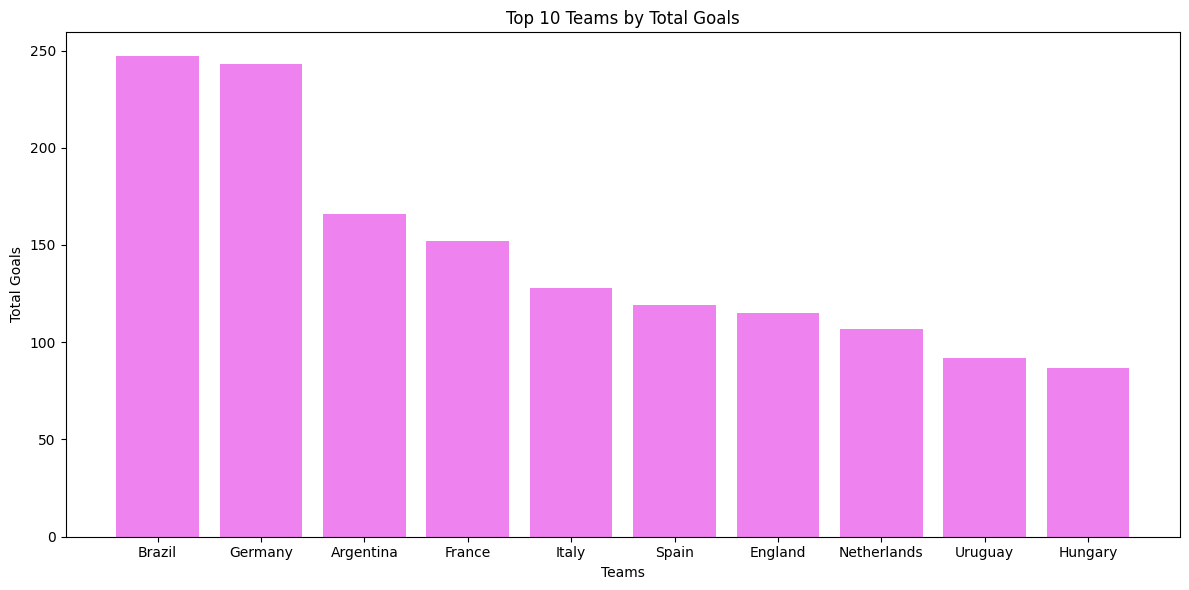

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.bar(total_goals.head(10).index, total_goals.head(10).values, color='violet')
plt.xlabel("Teams")
plt.ylabel("Total Goals")
plt.title("Top 10 Teams by Total Goals")
plt.tight_layout()
# plt.xticks(rotation=90)
plt.show()


## 5. 간단한 승부예측 해보기

### 5-1 팀 성적을 계산하는 '도구' 만들기

`def`를 사용하여 "팀 이름을 입력하면 성적을 출력하는 도구"를 만들기

In [80]:
def team_stats(team_name):
    home = df[df["home_team"] == team_name]
    away = df[df["away_team"] == team_name]
    
    total_matches = len(home) + len(away)
    total_wins = len(home[home["home_score"] > home["away_score"]]) + len(away[away["away_score"] > away["home_score"]])
    total_draws = len(home[home["home_score"] == home["away_score"]]) + len(away[away["away_score"] == away["home_score"]])
    total_losses = total_matches - total_wins - total_draws
    goals_scored = home["home_score"].sum() + away["away_score"].sum()

    total_stats = total_wins / total_matches * 100, total_draws / total_matches * 100, total_losses / total_matches * 100, goals_scored / total_matches
    return f"{total_stats[0]:.2f}%, {total_stats[1]:.2f}%, {total_stats[2]:.2f}%, {total_stats[3]:.2f} goals"

team_stats("Brazil")

'63.44%, 20.39%, 16.17%, 2.18 goals'

### 5-2 두 팀을 비교해 승자 예측하기

In [99]:
def predict_winner(team_a, team_b, data=wc):
    # 팀별 경기 수와 승리 수를 기반으로 승률 계산
    a_home = data[data["home_team"] == team_a]
    a_away = data[data["away_team"] == team_a]
    b_home = data[data["home_team"] == team_b]
    b_away = data[data["away_team"] == team_b]

    a_matches = len(a_home) + len(a_away)
    b_matches = len(b_home) + len(b_away)

    if a_matches == 0 or b_matches == 0:
        return "데이터가 부족해 예측할 수 없습니다."

    a_wins = len(a_home[a_home["home_score"] > a_home["away_score"]]) + len(a_away[a_away["away_score"] > a_away["home_score"]])
    b_wins = len(b_home[b_home["home_score"] > b_home["away_score"]]) + len(b_away[b_away["away_score"] > b_away["home_score"]])

    win_rate_a = a_wins / a_matches * 100
    win_rate_b = b_wins / b_matches * 100

    if win_rate_a > win_rate_b:
        winner = team_a
    elif win_rate_b > win_rate_a:
        winner = team_b
    else:
        winner = "무승부(동률)"

    return (
        f"{team_a} 승률: {win_rate_a:.2f}% | "
        f"{team_b} 승률: {win_rate_b:.2f}% | "
        f"예상 승자: {winner}"
    )

In [101]:
predict_winner("Brazil", "Germany")

'Brazil 승률: 66.39% | Germany 승률: 60.34% | 예상 승자: Brazil'

### 5-3 승리 예측해보기

2026.07.12 아르헨티나 vs 스위스

In [103]:
predict_winner("Argentina", "Switzerland")

'Argentina 승률: 55.32% | Switzerland 승률: 36.17% | 예상 승자: Argentina'